# **Práctica 3.1: Aprendizaje Automático (Clasificación)**

<hr>

## **1. Introducción**
Una vez hemos analizado, limpiado y visualizado nuestro conjunto, ya podemos pasar a la fase de aprendizaje. Antes comenzar es necesario identificar a que tipo de problema nos enfrentamos para poder seleccionar los métodos o modelos más adecuados.

En el siguiente diagrama se pueden ver los tipos de problemas más comunes dentro del campo del aprendizaje automático:

<center><img src="https://i.imgur.com/CN1RVmy.png" alt="diagram" width="1000"/></center>

Como ya sabes, los problemas que requieren de **aprendizaje automático** para ser resueltos son aquellos donde desconocemos la *fórmula* que nos permite transformar la entrada en la salida. Dentro de estos hay dos tipos principalmente, **supervisados** y **no supervisados**.

En esta asignatura nos centraremos en los problemas de aprendizaje supervisado, que son aquellos donde buscamos predecir, o bien una o varias clases (**clasificación**) o bien uno o varios valores numéricos (**regresión**). 

Recuerda que para poder resolver problemas de aprendizaje supervisado siempre vamos a necesitar **datos etiquetados**, es decir, datos donde ya conocemos, para una entrada dada, la salida esperada o etiqueta correcta. Estos datos serán los que utilice el modelo para intentar aprender esa *fórmula desconocida* durante el entrenamiento.


Vamos a comenzar por los **problemas de clasificación**, sus particularidades, métricas, técnicas de evaluación y cómo se utilizan para realizar predicciones.

### **Objetivo**
En esta práctica aprenderás a resolver problemas de clasificación utilizando diferentes modelos así como a evaluar su rendimiento. 


<hr>

## **2. Definición del problema**

Para comenzar vamos a intentar crear un modelo capaz de resolver un problema de **clasificación binaria**. 

En este caso se nos pide **crear un modelo que, dado el tiempo (en segundos) de los 3 sectores de un piloto de *Aston Martin*, se prediga si ese tiempo lo realizó *Alonso* o no (*Stroll*)**.

Vamos a cargar de nuevo nuestros datos y a generar el conjunto necesario para resolver el problema.


In [57]:
import pandas as pd
data = pd.read_pickle("https://raw.githubusercontent.com/AIC-Uniovi/Sistemas-Inteligentes/refs/heads/main/datasets/f1_23_monaco.pkl")

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea la variable <code>data_aston</code> con un DataFrame que contenga únicamente los datos de ese equipo y las columnas "Sector1Time", "Sector2Time", "Sector3Time" y "Driver"</a>. Transforma las columnas de los sectores de timedelta a segundos con <code>.dt.total_seconds()</code>
</div>

In [58]:
# Tu código aquí
aston = data.loc[(data["Driver"]== "ALO") | (data["Driver"]=="STR")]

data_aston = aston[["Sector1Time", "Sector2Time", "Sector3Time", "Driver"]]

data_aston["Sector1Time"].dt.total_seconds()
data_aston["Sector2Time"].dt.total_seconds()
data_aston["Sector3Time"].dt.total_seconds()

    

1       21.119
16      21.287
18      21.116
33      21.197
38      20.971
         ...  
1174    22.011
1192    21.899
1209    22.214
1227    21.588
1245    22.245
Name: Sector3Time, Length: 113, dtype: float64

Vamos a modificar el conjunto para transformarlo en un problema de clasificación binaria. Como recordarás, en ese tipo de problemas el modelo predice **un único valor** que indica la probabilidad entre cero ($0\%$) y uno ($100\%$) de que la entrada dada sea o no de la **clase positiva**.

En nuestro caso la **clase positiva** será *"Alonso"*, por tanto, si el modelo predice un $1$ nos estará diciendo que los tiempos de los 3 sectores dados en la entrada son de Alonso con un $100\%$ de probabilidad. 

Si la predicción del modelo es $0$, o menor de $0.5$, nos estará diciendo que la vuelta no es de Alonso y por tanto de Stroll.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea la columna <code>Class</code> dentro del DataFrame <code>data_aston</code> para que valga cero siempre que el piloto no sea Alonso y 1 en el caso contrario. 
</div>

In [59]:
# Tu código aquí
data_aston["Class"]= data_aston["Driver"].map({"ALO": 1, "STR": 0})

data_aston



C:\Users\uo288967\AppData\Local\Temp\ipykernel_6868\489250658.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_aston["Class"]= data_aston["Driver"].map({"ALO": 1, "STR": 0})


,Sector1Time,Sector2Time,Sector3Time,Driver,Class
1,0 days 00:00:20.871000,0 days 00:00:37.656000,0 days 00:00:21.119000,ALO,1
16,0 days 00:00:21.136000,0 days 00:00:37.566000,0 days 00:00:21.287000,STR,0
18,0 days 00:00:20.649000,0 days 00:00:37.348000,0 days 00:00:21.116000,ALO,1
33,0 days 00:00:21.084000,0 days 00:00:37.647000,0 days 00:00:21.197000,STR,0
38,0 days 00:00:20.584000,0 days 00:00:37.221000,0 days 00:00:20.971000,ALO,1
...,...,...,...,...,...
1174,0 days 00:00:23.068000,0 days 00:00:42.166000,0 days 00:00:22.011000,ALO,1
1192,0 days 00:00:22.592000,0 days 00:00:41.209000,0 days 00:00:21.899000,ALO,1
1209,0 days 00:00:23.072000,0 days 00:00:41.645000,0 days 00:00:22.214000,ALO,1
1227,0 days 00:00:22.164000,0 days 00:00:40.949000,0 days 00:00:21.588000,ALO,1


In [60]:
data_aston["Class2"] = data_aston["Driver"]

data_aston["Class2"] = (data_aston["Class2"] == "ALO").astype(int)

data_aston



C:\Users\uo288967\AppData\Local\Temp\ipykernel_6868\1296793285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_aston["Class2"] = data_aston["Driver"]
C:\Users\uo288967\AppData\Local\Temp\ipykernel_6868\1296793285.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_aston["Class2"] = (data_aston["Class2"] == "ALO").astype(int)


,Sector1Time,Sector2Time,Sector3Time,Driver,Class,Class2
1,0 days 00:00:20.871000,0 days 00:00:37.656000,0 days 00:00:21.119000,ALO,1,1
16,0 days 00:00:21.136000,0 days 00:00:37.566000,0 days 00:00:21.287000,STR,0,0
18,0 days 00:00:20.649000,0 days 00:00:37.348000,0 days 00:00:21.116000,ALO,1,1
33,0 days 00:00:21.084000,0 days 00:00:37.647000,0 days 00:00:21.197000,STR,0,0
38,0 days 00:00:20.584000,0 days 00:00:37.221000,0 days 00:00:20.971000,ALO,1,1
...,...,...,...,...,...,...
1174,0 days 00:00:23.068000,0 days 00:00:42.166000,0 days 00:00:22.011000,ALO,1,1
1192,0 days 00:00:22.592000,0 days 00:00:41.209000,0 days 00:00:21.899000,ALO,1,1
1209,0 days 00:00:23.072000,0 days 00:00:41.645000,0 days 00:00:22.214000,ALO,1,1
1227,0 days 00:00:22.164000,0 days 00:00:40.949000,0 days 00:00:21.588000,ALO,1,1


<hr>

## **3. Baseline**

Una vez disponemos de un conjunto de datos etiquetados, donde cada entrada (Sector1Time, Sector2Time y Sector3Time) está asociada a una salida esperada (Class), podemos proceder a crear un modelo para resolver el problema de clasificación binaria

Como se ha explicado en clase de teoría, existen modelos sencillos que pueden ofrecer muy buen rendimiento sin necesidad de recurrir a soluciones más complejas. 
Estos modelos se denominan *baselines* y nos sirven para tener una referencia o un límite inferior. Si un baseline tiene mejor rendimiento que un modelo mucho más complejo, algo está funcionando mal. 

En problemas de clasificación destacan principalmente tres:

* **Aleatorio:** Predice aleatoriamente un 0 o un 1 sin tener en cuenta las variables de entrada.
* **Zero-R:** Predice la clase mayoritaria, es decir, analiza la columna "Class" del conjunto de datos y, si la clase que más aparece es 1, siempre predice, ante cualquier entrada, un 1. Como ves, tampoco utiliza para nada las variables de la entrada.
* **One-R:** Este modelo selecciona **una** variable de la entrada, aquella que por sí sola ofrezca la mejor clasificación posible. Pensado para variables de entrada de tipo categórico.

<div class="alert alert-block alert-warning">
    <strong>NOTA:</strong> Utilizaremos <i>Aleatorio</i> y <i>Zero-R</i> como baselines para nuestro problema. <i>One-R</i> no es posible, nuestras variables de entrada son numéricas.
</div>

### **Baseline aleatorio**
Vamos a crear un modelo que genere predicciones aleatorias (0 o 1) independientemente de las variables de entrada. 

La implementación es muy sencilla, simplemente hay que generar una lista aleatoria de ceros y unos. A continuación contaremos cuantas veces ha acertado el modelo.

In [61]:
import random

# Fijamos una semilla para que siempre se generen los mismos valores aleatorios
seed = 2533
random.seed(seed)
# Creamos una lista de tantos valores (0 o 1) como filas tiene nuestro conjunto
random_values = [random.choice([0, 1]) for _ in range(len(data_aston))]

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> ¿Cuántas veces ha acertado el modelo (en porcentaje)? Para obtenerlo tendrás que contar cuantas veces el modelo aleatorio dijo un 1 y realmente era un 1 y cuantas dijo un 0 y realmente era un 0.
</div>

In [62]:
# Tu código aquí
contador = 0
for i in range(len(data_aston)):
    if data_aston["Class"].iloc[i]== random_values[i]:
        contador+=1

print(len(data_aston))
print((contador/len(data_aston))*100)

# (data_aston["Class"] == random_values).sum()/len(random_values)

113
35.39823008849557


<div class="alert alert-block alert-success">
    Ese valor que acabas de obtener, es una de las <strong>métricas</strong> más populares de <strong>clasificación</strong> y se denomina <strong>accuracy</strong>. Simplemente cuenta el número de aciertos del modelo sobre el máximo posible.
</div>

### **Zero-R**
A continuación obtendremos el resultado del baseline *Zero-R*.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> ¿Cuál es la clase mayoritaria del conjunto de datos? Teniendo esto en cuenta, ¿Cuál será la <strong>accuracy</strong> del <i>Zero-R</i>?
</div>

In [63]:
# Tu código aqui
alo= 0
str= 0
cont= 0

for i in range(len(data_aston)):            # for i in data_aston["Class"]:
    if data_aston["Class"].iloc[i]== 1:     #   if i == 1
        alo+=1
    else:
        str+=1
        
if alo > str: mayor= 1
else: mayor = 0

for i in range(len(data_aston)):                     # for i in data_aston["Class"]:
    if data_aston["Class"].iloc[i]== mayor:          #  if i == mayor
        cont+=1
        
print(cont)
print(len(data_aston))   
     
print(cont/(len(data_aston))*100)


# Otra solucion
# data_aston["Class"].sum()/len(data_aston)*100


66
113
58.4070796460177


## **4. Evaluación del modelo**

En este punto **ya tenemos dos modelos** capaces de resolver nuestro problema de clasificación binaria, el **Aleatorio** y el **Zero-R**. Además, ya sabemos que estos modelos tienen una accuracy en **resustitución** de aproximadamente un $35\%$ y $60\%$.

<div class="alert alert-block alert-warning">
    <strong>Resustitución:</strong> Proceso por el que un modelo <u>se entrena y evalúa utilizando el mismo conjunto</u>. Este procedimiento puede ofrecer una estimación inicial del rendimiento del modelo, aunque <strong>no refleja su capacidad de generalización</strong>.
</div>

Es importante recordar que cuando creamos un modelo de aprendizaje automático buscamos que este no solo funcione bien con los datos conocidos, **sino que sea capaz de realizar predicciones sobre datos nuevos y no vistos**.

Con esto en mente, podemos notar que la evaluación que acabamos de realizar sobre nuestros modelos no es del todo adecuada. Lo que hemos medido es qué tan bien predicen los ejemplos que ya conocen, pero no su capacidad para hacer predicciones sobre datos futuros, que es lo realmente relevante.


### **Estrategias**
Para solucionar este problema, en lugar de evaluar el modelo sobre los mismos datos con los que ha aprendido, vamos a evaluarlo sobre una parte del conjunto que habremos separado previamente (conjunto de prueba o test).

Ese subconjunto se suele crear apartando del conjunto original un porcentaje ($20\%$ típicamente) de ejemplos seleccionados aleatoriamente y se utilizará únicamente para evaluar el rendimiento del modelo, no para entrenar. Haciendo esto, *"simularemos"* casos futuros no vistos y, si el modelo tiene buena accuracy sobre este conjunto, sabremos que es bueno realmente.

Esta estrategia se denomina **Validación simple**, pero existen muchas otras: 

- **Validación cruzada**: Consiste en dividir los datos en varios subconjuntos (*folds*), entrenar el modelo en algunos de ellos y evaluarlo en los restantes, repitiendo el proceso varias veces. Esto ayuda a obtener una estimación más estable del desempeño del modelo.  
- **Validación con conjunto de validación**: Se emplea un tercer subconjunto, distinto del de test, para ajustar los hiperparámetros del modelo y evitar el sobreajuste. Muy típico cuando se utilizan redes neuronales.  

Para obtener una evaluación más realista del rendimiento de nuestros modelos, vamos a aplicar **validación simple** y obtener de nuevo su accuracy, pero esta vez sobre el conjunto de test.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Separa el conjunto <code>data_aston</code> en entrenamiento y test (80% y 20%) y almacena los subconjuntos en <code>data_aston_train</code> y <code>data_aston_test</code>. Utiliza para ello la función <code><a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html">train_test_split()</a></code> de la librería <i>scikit-learn</i> que tendrás que instalar en tu environment conda previamente. 
    <hr>
    <strong>Fija la semilla de la función para que siempre realize la misma división (random_state=2533)</strong>
</div>

In [64]:
# Tu código aquí
from sklearn.model_selection import train_test_split

data_aston_train, data_aston_test = train_test_split(data_aston, train_size = 0.8, random_state=2533)

print(len(data_aston)) , 
print(len(data_aston_test)),
print(len(data_aston_train))

113
23
90


<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> ¿Cuál es ahora la accuracy del Aleatorio sobre el conjunto de test?. Recuerda volver a fijar la semilla.
</div>

In [65]:
# Tu código aquí
random_state = 2533
random.seed(random_state)
random_values = [random.choice([0, 1]) for _ in range(len(data_aston_test))]


(data_aston_test["Class"]== random_values).sum()/ (len(random_values))*100


np.float64(56.52173913043478)

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> ¿Cuál es ahora la accuracy del Zero-R sobre el conjunto de test?.
    <hr>
    Recuerda que has de recalcular la clase mayoritaria utilizando el nuevo conjunto de entrenamiento (es lo único que debería conocer tu modelo) y con ella evaluar en test.
</div>

In [66]:
# Tu código aquí
alo= 0
str= 0
cont= 0

for i in range(len(data_aston_test)):            # for i in data_aston["Class"]:
    if data_aston_test["Class"].iloc[i]== 1:     #   if i == 1
        alo+=1
    else:
        str+=1
        
if alo > str: mayor= 1
else: mayor = 0

print(mayor)

for i in range(len(data_aston_test)):                     # for i in data_aston["Class"]:
    if data_aston_test["Class"].iloc[i]== mayor:          #  if i == mayor
        cont+=1

print(cont/len(data_aston_test)*100)

#Otra opcion
data_aston_train["Class"].mean()
data_aston_test["Class"].sum()/len(data_aston_test)   






1
56.52173913043478


np.float64(0.5652173913043478)

Como acabas de ver, los modelos han obtenido valores muy cercanos al $50\%$ de accuracy en test, lo que deja mucho que desear.

<div class="alert alert-block alert-warning">
    <strong>Nota:</strong> El peor modelo de clasificación binaria posible tendrá un 50% de accuracy, no un 0%. Uno con el 0% estaría acertando todo, pero habría que invertir sus predicciones. 
</div>


<hr>

## **5. Scikit-Learn**

La librería `Scikit-learn` utilizada previamente, posee una gran cantidad de modelos y herramientas que nos serán de utilidad para resolver problemas de aprendizaje automático.

Por ejemplo, los baselines que acabamos de implementar ya vienen incorporados dentro de la clase `DummyClassifier()`.

Esta clase posee el parámetro `strategy` que nos permite seleccionar el baseline deseado y puede tomar, entre otros, los siguientes valores:
- **uniform**: Equivalente a nuestro *Aleatorio*. 
- **most_frequent**: Equivalente a *Zero-R*. 

En el siguiente código vemos cómo podemos utilizar esta clase:

In [67]:
from sklearn.dummy import DummyClassifier

# Creamos los modelos
baseline_aleatorio = DummyClassifier(strategy="uniform", random_state=seed)
baseline_zeror = DummyClassifier(strategy="most_frequent")

Una vez creados los modelos, el siguiente paso es entrenarlos, y para ello hay que proporcionales, mediante el método `fit()`. los datos de entrenamiento, en concreto la $X$ y la $Y$.

<div class="alert alert-block alert-warning">
    <strong>Nota:</strong> En aprendizaje supervisado, denominamos X a las variables independientes o <i>entradas</i> e Y a las variables dependientes o <i>salidas</i>. 
</div>

Como ya sabes, el objetivo del modelo es *aprender* la relación entre $X$ e $Y$ para poder predecir la $Y$ a partir de nuevas $X$ desconocidas. 

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea las variables X e Y para entrenar los modelos. Recuerda que hemos dividido el conjunto en dos partes.
</div>

In [68]:
# Tu código aquí ->Para entrenar solo se usa el train
X = data_aston_train[["Sector1Time","Sector2Time","Sector3Time"]]
Y = data_aston_train["Class"]

# Entrenamos
baseline_aleatorio.fit(X, Y)
baseline_zeror.fit(X, Y)

,strategy,'most_frequent'
,random_state,None
,constant,None


Una vez tenemos el modelo entrenado, ya podemos realizar predicciones para evaluar su desempeño con datos no vistos durante el entrenamiento. En `scikit-learn` esto se hace mediante la función `predict()`.

<div class="alert alert-block alert-warning">
    <strong>Nota:</strong> Esta función solo recibe las X (no las Y) y retorna las Y predichas. 
</div>

In [69]:
X_test = data_aston_test[["Sector1Time","Sector2Time","Sector3Time"]]
Y_test = data_aston_test[["Class"]]

# Predecir
pred_aleatorio = baseline_aleatorio.predict(X_test)
pred_zeror = baseline_zeror.predict(X_test)

# Imprimir resultados
print(pred_aleatorio)
print(pred_zeror)

[1 0 0 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 0 1 1 1 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


Otra ventaja de esta librería es que trae implementadas multitud de métricas dentro del paquete `metrics`, por lo que podremos obtener la accuracy de manera muy sencilla.

In [70]:
from sklearn import metrics

print(metrics.accuracy_score(Y_test, pred_aleatorio))
print(metrics.accuracy_score(Y_test, pred_zeror))

0.5652173913043478
0.5652173913043478


<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Obtén las matrices de confusión de los modelos utilizando <a href="https://scikit-learn.org/stable/api/sklearn.metrics.html">el método implementado en la librería</a>. Obtén también la <i>Precission, Recall y F1</i> con los métodos o las fórmulas.
</div>

<div style="width:800px;background:white;padding:10px">
    <img src="https://i.imgur.com/7WwY9bZ.jpeg" style="margin-bottom:10px"> </img>
</div>

In [71]:
# Tu código aquí
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

print("Matriz:",confusion_matrix(Y_test,pred_aleatorio))
print("Recall: ", recall_score(Y_test,pred_aleatorio))
print("Precision: ", precision_score(Y_test,pred_aleatorio))
print("F1: ", f1_score(Y_test,pred_aleatorio))



Matriz: [[6 4]
 [6 7]]
Recall:  0.5384615384615384
Precision:  0.6363636363636364
F1:  0.5833333333333334


<hr>

## **6. Otros modelos**

Como ya has visto en clase de teoría, además de los baselines que acabamos utilizar, existen muchos otros modelos diferentes para resolver problemas de clasificación. Algunos de ellos pueden ser: 

* **Regresión logistica:** Modelo "lineal" que utiliza una función logística (sigmoide) para predecir la probabilidad de pertenencia a una clase.
* **K-Nearest Neighbors:** Clasificador que asigna una instancia a la clase más frecuente entre sus k vecinos más cercanos.
* **Arboles de decisión:** Modelo de clasificación que crea un árbol que permite tomar decisiones basadas en las características de los datos (entradas).
* **SVM:** Algoritmo de clasificación que busca el hiperplano óptimo que maximiza el margen entre las clases.
* **Redes Neuronales:** Las veremos en detalle en los próximos temas.

Al igual que sucedía con los baselines, `scikit-learn` nos proporciona muchos la mayoría ya implementados.

<div class="alert alert-block alert-warning">
    <strong>Nota:</strong> Antes de utilizar otros modelos, es necesario llevar a cabo una fase del <u>preprocesamiento de datos</u> que teníamos pendiente: La <strong>normalización o la estandarización</strong> de datos. 
</div>

Como recordarás, esta fase se encarga de que todas las <u>entradas</u> a nuestro modelo (tiempos de sectores en nuestro caso) se muevan en el mismo rango (normalización) o tengan la misma media y desviación (estandarización) para facilitar el aprendizaje.

Hasta ahora no lo hemos realizado por que los baselines anteriores no utilizaban para nada la información de entrada, uno predecía de forma aleatoria y el otro predecía la clase más frecuente.

Realizaremos, en este caso una estandarización (una normalización también sería válida). Vamos a verificar la media y desviación de las entradas previamente.

In [72]:
# Media y desviación de las entradas de nuestro modelo
X.describe().loc[["mean", "std"]]

,Sector1Time,Sector2Time,Sector3Time
mean,0 days 00:00:20.902277777,0 days 00:00:37.992333333,0 days 00:00:21.259766666
std,0 days 00:00:01.376839313,0 days 00:00:02.680777847,0 days 00:00:00.959350881


<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Utiliza el <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html"><code>StandardScaler()</code></a> de <i>sklearn</i> para estandarizar las X de train y de test. Almacena los nuevos datos en <code>X_std</code> y <code>X_test_std</code>. Recuerda que los datos de test son desconocidos para nosotros, por lo que no pueden influir a la hora de calcular la media y las desviación.
</div>

In [77]:
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()
# Tu código aquí
standarizer = StandardScaler()
standardizer.fit(X)
X_std = standardizer.transform(X)
X_test_std = standardizer.transform(X_test)

# Verifica con: 
print(X_std.mean(axis=0))
print(X_std.std(axis=0))

[-6.24192056e-16 -9.65894031e-16 -1.33473479e-15]
[1. 1. 1.]


### **6.1. Regresión Logística**

Ya tenemos todo listo para entrenar y evaluar nuevos modelos <u>buscando mejorar las métricas de los baselines</u>. Comenzaremos por la **Regresión logística**.

Para utilizarla simplemente tendremos que crear un objeto de la clase `LogisticRegression()`, entrenarlo con el `fit()` y evaluarlo con `predict()`.

In [78]:
from sklearn.linear_model import LogisticRegression

# Creamos, entrenamos y evaluamos el modelo
model_log = LogisticRegression()
model_log.fit(X_std, Y.squeeze()) # El squeeze elimina dimensiones innecesarias
pred_log = model_log.predict(X_test_std)
print(metrics.accuracy_score(Y_test, pred_log))

0.6086956521739131


Como ves, este modelo obtiene mejores resultados en términos de accuracy, pero no mucho mejores.

Podemos visualizar también su **matriz de confusión**:

Text(0.5, 1.0, 'Matriz de confusión')

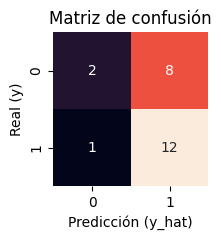

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_mat_log = metrics.confusion_matrix(Y_test, pred_log)

plt.figure(figsize=(2,2)); # Tamaño del plot
sns.heatmap(conf_mat_log, annot=True, cbar=False)
plt.ylabel("Real (y)")
plt.xlabel("Predicción (y_hat)")
plt.title("Matriz de confusión")

### **6.2. K-Nearest Neighbors**

El siguiente modelo que podemos probar es el `KNeighborsClassifier()`, que se usa exactamente igual que el resto.

In [80]:
from sklearn.neighbors import KNeighborsClassifier

# Creamos, entrenamos y evaluamos el modelo
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_std, Y.squeeze())
pred_knn = model_knn.predict(X_test_std)
print(metrics.accuracy_score(Y_test, pred_knn))

0.9565217391304348


Los resultados en términos de accuracy con este modelo son muy próximos al $100\%$, lo que lo hace el mejor de los evaluados.

### **6.3. Árboles de decisión**
A continuación analizaremos el rendimiento que tiene un árbol de decisión a la hora de resolver esta tarea. La clase dentro de la librería se denomina `DecisionTreeClassifier()` y presenta numerosos hiperparámetros, siendo uno de los más destacados `max_depth`, que permite establecer la profundidad máxima del árbol y por tanto controlar el **sobreajuste**.


In [81]:
from sklearn.tree import DecisionTreeClassifier

# Creamos, entrenamos y evaluamos el modelo
model_tree = DecisionTreeClassifier(random_state=seed, max_depth=2)
model_tree.fit(X_std, Y.squeeze())
pred_tree = model_tree.predict(X_test_std)
print(metrics.accuracy_score(Y_test, pred_tree))

0.9565217391304348


El rendimiento es similar al modelo anterior, pero este posee la ventaja de permitirnos ver su funcionamiento interno, es decir, el árbol que ha creado. Para ello, tendremos que instalar una nueva librería.

In [85]:
! pip install pydotplus


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [86]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus

# Exportamos el árbol resultante a formato DOT
dot_data = export_graphviz(decision_tree=model_tree, feature_names=X.columns, class_names=['Stroll', 'Alonso'], filled=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

ModuleNotFoundError: No module named 'pydotplus'

### **6.4. Support Vector Machines (SVM)**
El último modelo que vamos a probar es el SVM y está implementado en la clase `SVC()`. Comenzaremos por un **kernel lineal**.

In [ ]:
from sklearn.svm import SVC

# Creamos un SVM con kernel lineal entrenamos y evaluamos
model_svm = SVC(kernel='linear')
model_svm.fit(X_std, Y.squeeze())
pred_svm = model_svm.predict(X_test_std)
print(metrics.accuracy_score(Y_test, pred_svm))

La accuracy no es muy alta, por lo que es posible que las clases no sean **linealmente separables**. 

Para mejorar el rendimiento probaremos ahora con un **kernel polinómico** de grado 2.

In [ ]:
# Creamos un SVM con kernel polinómico de grado 2 y término independiente 1. Entrenamos y evaluamos
model_svm_p = SVC(kernel='poly', degree=2, coef0=1)
model_svm_p.fit(X_std, Y.squeeze())
pred_svm_p = model_svm_p.predict(X_test_std)
print(metrics.accuracy_score(Y_test, pred_svm_p))

Como ves, la no linealidad de este modelo permite resolver el problema con una precisión idéntica a los mejores modelos.

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Completa la función <code>train_and_eval()</code> para el resto de modelos incluyendo las dos versiones del SVM. Esta hace uso de la función <code>train_and_eval_model()</code> implementada a continuación.

In [ ]:
def train_and_eval_model(model_name, model, X_std, Y, X_test_std, Y_test):
    # Entrenar el modelo
    model.fit(X_std, Y.squeeze())
    # Predicciones
    Y_train_pred = model.predict(X_std)
    Y_test_pred = model.predict(X_test_std)
    # Calcular métricas para train
    tr_accuracy = metrics.accuracy_score(Y, Y_train_pred)
    tr_precision = metrics.precision_score(Y, Y_train_pred, zero_division=0)
    tr_recall = metrics.recall_score(Y, Y_train_pred)
    tr_f1 = metrics.f1_score(Y, Y_train_pred)
    
    # Calcular métricas para test
    tst_accuracy = metrics.accuracy_score(Y_test, Y_test_pred)
    tst_precision = metrics.precision_score(Y_test, Y_test_pred, zero_division=0)
    tst_recall = metrics.recall_score(Y_test, Y_test_pred)
    tst_f1 = metrics.f1_score(Y_test, Y_test_pred)
    return (model_name, 
            tr_accuracy, tr_precision, tr_recall, tr_f1, 
            tst_accuracy, tst_precision, tst_recall, tst_f1)

In [ ]:
def train_and_eval(X_std, Y, X_test_std, Y_test):
    # Creamos una lista donde almacenar los resultados de cada modelo
    all_results = []
    
    # Baseline aleatorio
    baseline_aleatorio = DummyClassifier(strategy="uniform", random_state=seed)
    model_results = train_and_eval_model("Aleatorio", baseline_aleatorio, X_std, Y, X_test_std, Y_test)
    all_results.append(model_results)
    
    # Tu código aquí

    # Imprimir el dataframe resultante
    multi_index = pd.MultiIndex.from_tuples([ ("Modelo", "Nombre"), ("Train", "Accuracy"), ("Train", "Precision"), ("Train", "Recall"), ("Train", "F1"), ("Test", "Accuracy"), ("Test", "Precision"), ("Test", "Recall"), ("Test", "F1") ])    
    all_results = pd.DataFrame(all_results, columns=multi_index)
    display(all_results)

train_and_eval(X_std, Y, X_test_std, Y_test)

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> ¿Cuál crees que es el mejor modelo? ¿Por qué?

In [ ]:
# Tu respuesta aquí

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea un modelo capaz de predecir, a partir de los 3 sectores de un piloto, si el neumático con el que realizó la vuelta es de lluvia ("INTERMEDIATE" o "WET") o no. Realiza todo el preprocesamiento que creas necesario y prueba todos los modelos de clasificación vistos hasta ahora utilizando la función anterior.
</div>

In [ ]:
# Tu código aquí